In [1]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
import keras

In [2]:
# Constructing the exact BW peaks
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
#A = np.array([0.8,1.0])
#Ga = np.array([0.5,0.5])
#M = np.array([2.0,5.0])
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]

In [3]:
def BWfun(Aa,Gamma,Mass,Omega):
    num_peaks = len(Aa)

    sum_peak = np.zeros_like(Omega)

    for i in range(num_peaks):
        num = 4.0*Aa[i]*Gamma[i]*Omega;
        den = (Mass[i]**2 + Gamma[i]**2 - Omega**2)**2 + 4.0*(Gamma[i]**2)*(Omega**2)
        sum_peak += num/den

    return sum_peak

In [26]:
spec1BW = BWfun(A,Ga,M,omega)

In [25]:
# Constructing the training data - preparing the discrete kernel and convoluting
# Following the paper with grid of Np=25 and Nw=500
epsilon = 1.0e-4
p = np.linspace(epsilon,19.2+epsilon,25)
del_pi = p[1]-p[0]

In [24]:
def KL_kernel(Momentum, Omega):
    Momentum = Momentum[:, np.newaxis]  # Reshape Momentum as column to allow broadcasting
    ker = Omega / (Omega**2 + Momentum**2)  # Element-wise division

    return ker / np.pi 
    
kl_ker = KL_kernel(p,omega)

In [7]:
# Reconstructing the correlator - this function will also be used for the reconstruction in the NN:
def Di(KL, rhoi, delomega):
    # Ensure KL and rhoi are both float32 before performing matmul
    rhoi = tf.cast(rhoi, dtype=tf.float32)
    KL = tf.cast(KL, dtype=tf.float32)
    delomega = tf.cast(delomega, dtype=tf.float32)

    # Matrix multiplication
    dis = tf.matmul(KL, tf.expand_dims(rhoi, axis=-1))  # Matrix multiplication -> [25, 1]
    dis = tf.squeeze(dis, axis=-1)  # Remove the singleton dimension -> [25]
    dis = dis * delomega  
    return dis


In [29]:
def Di(KL, rhoi, delomega):
    # Ensure both tensors are of the same data type (float64)
    KL = tf.cast(KL, dtype=tf.float64)  # Cast KL to float64
    rhoi = tf.cast(rhoi, dtype=tf.float64)  # Cast rhoi to float64
    delomega = tf.cast(delomega, dtype=tf.float64)  # Cast delomega to float64
    
    # Ensure rhoi has the correct shape [500,1] for matrix multiplication
    rhoi = tf.reshape(rhoi, [-1, 1])  # Reshape to [500, 1]

    # Perform matrix multiplication
    dis = tf.matmul(KL, rhoi)  # Shape will be [25, 1]
    dis = tf.squeeze(dis, axis=-1)  # Remove the singleton dimension to get [25]
    
    dis = dis * delomega  # Multiply by delomega
    return dis

In [30]:
Dpi = Di(kl_ker,spec1BW,del_omega)

In [110]:
# Adding noise to the correlator, ep_noise can be 1.0e-5,-4,-3
ep_noise = 1.0e-3
custom_std = ep_noise*(Dpi*p)/del_pi
noisy_Dpi = Dpi + np.random.normal(0,custom_std)


In [132]:
#s regularization term - extra step in paper to make rho smooth
def smoothness_loss(rho):
    diff = rho[:, 1:] - rho[:, :-1]
    return tf.reduce_sum(tf.square(diff))

# L2 regularization term
def l2_regularization(weights):
    return tf.reduce_sum([tf.reduce_sum(tf.square(w)) for w in weights])

# Loss function
def custom_loss(y_true, y_pred,gauss_width):
    # Ensure both y_true and y_pred are of type float32
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)
    gauss_width = tf.cast(gauss_width, dtype=tf.float32)

    chi_squared = tf.square((y_true - y_pred) / gauss_width)
    
    return tf.reduce_mean(chi_squared)  

# Total loss function
def total_loss(main_loss, rho, model, lambda_s, lambda_l2):
    # Smoothness loss
    smooth_loss = smoothness_loss(rho)
    
    # L2 loss (regularization on the network weights)
    l2_loss = l2_regularization(model.trainable_weights)
    
    # Total loss = main loss + smoothness regularizer + L2 regularization
    return main_loss + lambda_s * smooth_loss + (lambda_l2 * l2_loss)*0.5

In [172]:
# Modify the CustomTrainingModel's train_step method to include kl_ker and del_omega
class CustomTrainingModel(tf.keras.Model):
    def __init__(self, num_output_nodes, width=64, depth=3, lambda_s=None, lambda_l2=None, kl_ker=None, del_omega=None, gauss_width=None):
        super(CustomTrainingModel, self).__init__()
        self.lambda_s = lambda_s
        self.lambda_l2 = lambda_l2
        self.kl_ker = kl_ker
        self.del_omega = del_omega
        self.gauss_width = gauss_width
        
        # Input layer and hidden layers
        self.dense1 = tf.keras.layers.Dense(width, activation='elu')
        self.dense2 = tf.keras.layers.Dense(width, activation='elu')
        # Output layer that produces one output per frequency (500 outputs)
        self.output_layer = tf.keras.layers.Dense(1, activation='softplus')
    
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.output_layer(x)

# Train the model using `fit`-didn't work beacuse input-output dimensions don't match
# THE ONLY CHANGE IS AT THIS STEP - now the input and output layer are 500 each like the P2P paper
constant_input = tf.constant(omega, dtype=tf.float32) 
constant_input = tf.reshape(constant_input, (-1, 1))
target_output = tf.constant(noisy_Dpi)
#gauss_width = custom_std
gauss_width = np.ones(25)
lambda_s = 0
lambda_l2 = 0.5*1.0e-5
lambda_reg = 0
# Initialize the model
model = CustomTrainingModel(num_output_nodes=500, width=64, depth=3, lambda_s=lambda_s, lambda_l2=lambda_l2, kl_ker=kl_ker, del_omega=del_omega, gauss_width=gauss_width)

# Compile the model
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)

epochs=5000
# Custom Training Loop

for epoch in range(epochs):
    
    with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
        rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
        y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
        # Compute custom loss (Chi-squared loss + regularizations)
        main_loss = custom_loss(target_output, y_pred, gauss_width)
        total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s, lambda_l2 )
    
    # Compute gradients and update weights
    gradients = tape.gradient(total_loss_value, model.trainable_weights)
    optimizer.apply_gradients(zip(gradients, model.trainable_weights))
    
    #print(f"Loss: {total_loss_value.numpy()}")

print("Warm up complete.")

optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5,weight_decay=lambda_reg)
new_epochs = 100000
loss_history = []
for epoch in range(new_epochs):
    #print(f'Resuming Epoch {epoch + 1}/{new_epochs}')
    
    with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
        rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
        y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
        # Compute custom loss with updated lambda_s and lambda_l2
        main_loss = custom_loss(target_output, y_pred, gauss_width)
        total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s=0, lambda_l2=0)
    
    # Compute gradients and update weights
    gradients = tape.gradient(total_loss_value, model.trainable_weights)
    optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    #print(f"Loss: {total_loss_value.numpy()}")
    loss_history.append(total_loss_value.numpy())

print("Training up complete.")

Warm up complete.
Training up complete.


In [34]:
tf.shape(rhoi_pred)

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([500,   1], dtype=int32)>

In [173]:
Final_rhoiL2 = tf.squeeze(rhoi_pred, axis=-1)  # Now it will have shape [batch_size]
Final_DpiL2 = y_pred.numpy().reshape(-1)

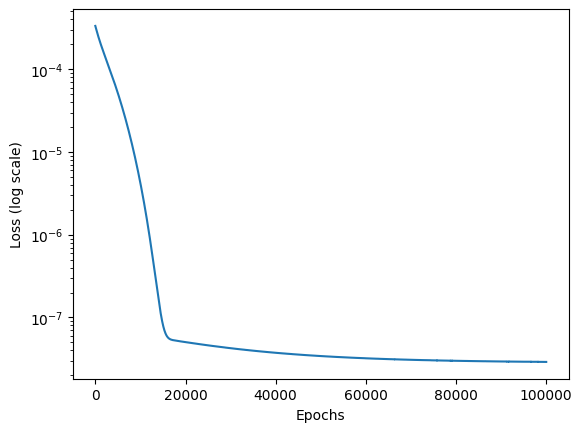

In [174]:
# Plotting loss history
plt.plot(range(new_epochs), loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.yscale('log') 
#plt.title('Training Loss Over Epochs 1BW with mean square')
#plt.savefig('NN_Training_loss_1peak_10K.png')
plt.show()

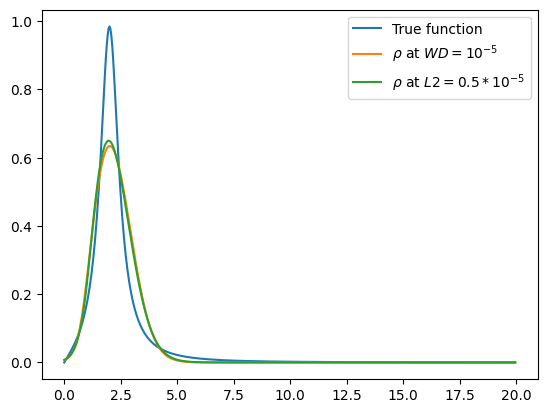

In [179]:
plt.plot(omega,spec1BW, label = r'True function' )
#plt.plot(omega,Final_rhoi0, label=r'$\rho$ at $L2 = 0$')
#plt.plot(omega,Final_rhoiL3, label=r'$\rho$ at $L2 = 10^{-7}$')
plt.plot(omega,Final_rhoiWD, label=r'$\rho$ at $WD = 10^{-5}$')
plt.plot(omega,Final_rhoiL2, label=r'$\rho$ at $L2 = 0.5*10^{-5}$')
#plt.plot(omega,Final_rhoiL2, label=r'$\rho$ at $L2 = 10^{-2}$')
#plt.plot(omega,Final_rho, label=r'$\rho$')
#plt.title(r'error 1.0e-3 on D(p_i) Multi-Fit Single Rho')
plt.legend()
#plt.savefig('NNP2P_Comparison_Rho_vsL21em3.png')
plt.show()

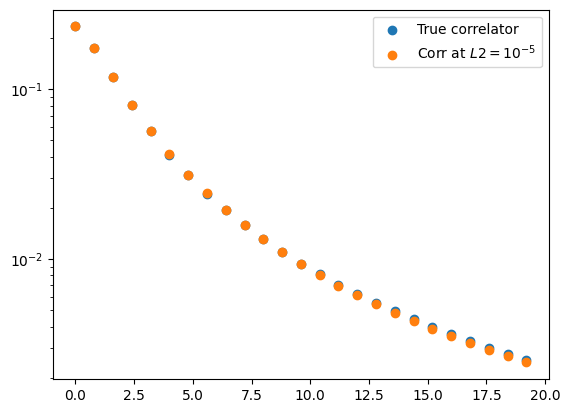

In [171]:
plt.scatter(p,Dpi, label=r'True correlator')
#plt.scatter(p,Final_Dpi0, label=r'Corr at $L2 = 0$')
#plt.scatter(p,Final_DpiL3, label=r'Corr at $L2 = 10^{-7}$')
plt.scatter(p,Final_DpiWD, label=r'Corr at $L2 = 10^{-5}$')
#plt.scatter(p,Final_DpiL2, label=r'Corr at $L2 = 10^{-2}$')
#plt.ylim(0.0,0.004)
plt.yscale('log')
#plt.xlim(10,20)

#plt.title('1 BW Peak 5000 epochs error 1e-3')
plt.legend()
#plt.savefig('NNP2P_Comparison_Dpi_vsL21em3.png')
plt.show()